In [ ]:
import scipy.io as sio
mat = sio.loadmat('data/training_dataset/training_data/annotations/Buffy_1.mat',
                  squeeze_me=True, struct_as_record=False)
boxes = mat['boxes']
print(f'Number of hands: {len(boxes) if hasattr(boxes, "__len__") else 1}')
for i, box in enumerate(boxes if hasattr(boxes, "__len__") else [boxes]):
    print(f'  Hand {i}: a={box.a}, b={box.b}, c={box.c}, d={box.d}')

Number of hands: 2
  Hand 0: a=[488.42954942 345.62261032], b=[461.57045058 348.37738968], c=[465.57045058 387.37738968], d=[492.42954942 384.62261032]
  Hand 1: a=[449.81237318 397.24488989], b=[462.18762682 426.75511011], c=[493.18762682 413.75511011], d=[480.81237318 384.24488989]


In [ ]:
import os
import json
import numpy as np
import scipy.io as sio
from PIL import Image


def convert(annotations_dir: str, images_dir: str, output_path: str):
    coco = {
        "images": [],
        "annotations": [],
        "categories": [{"id": 1, "name": "hand"}],
    }

    image_id = 0
    annotation_id = 0

    for file in sorted(os.listdir(annotations_dir)):
        if not file.endswith('.mat'):
            continue

        img_filename = file.replace('.mat', '.jpg')
        img_path = os.path.join(images_dir, img_filename)

        if not os.path.exists(img_path):
            print(f"Skipping {file}: image {img_filename} not found")
            continue

        with Image.open(img_path) as img:
            W, H = img.size

        coco['images'].append({
            'id': image_id,
            'file_name': img_filename,
            'width': W,
            'height': H,
        })

        mat = sio.loadmat(os.path.join(annotations_dir, file),
                          squeeze_me=True, struct_as_record=False)
        boxes = mat['boxes']
        if not isinstance(boxes, np.ndarray):
            boxes = [boxes]

        for box in boxes:
            xs = [corner[1] for corner in [box.a, box.b, box.c, box.d]]  # [y, x] → x
            ys = [corner[0] for corner in [box.a, box.b, box.c, box.d]]  # [y, x] → y
            x_min, x_max = min(xs), max(xs)
            y_min, y_max = min(ys), max(ys)
            w, h = x_max - x_min, y_max - y_min

            segmentation = [c for corner in [box.a, box.b, box.c, box.d]
                              for c in (corner[1], corner[0])]

            coco['annotations'].append({
                'id': annotation_id,
                'image_id': image_id,
                'category_id': 1,
                'bbox': [x_min, y_min, w, h],
                'area': w * h,
                'iscrowd': 0,
                'segmentation': [segmentation],
            })
            annotation_id += 1

        image_id += 1

    with open(output_path, 'w') as f:
        json.dump(coco, f)

    print(f"Wrote {len(coco['images'])} images, "
          f"{len(coco['annotations'])} annotations to {output_path}")


if __name__ == '__main__':
    splits = [
        ('data/training_dataset/training_data',   '../train.json'),
        ('data/validation_dataset/validation_data', '../val.json'),
        ('data/test_dataset/test_data',           '../test.json'),
    ]

    for split_dir, output in splits:
        ann_dir = os.path.join(split_dir, 'annotations')
        img_dir = os.path.join(split_dir, 'images')
        convert(ann_dir, img_dir, output)

In [1]:
from src.Data import HandDataset

train_dataset = HandDataset('train.json', 'data/training_dataset/training_data/images')
val_dataset = HandDataset('val.json','data/validation_dataset/validation_data/images')


In [2]:
NUM_CLASSES = 2
BATCH_SIZE = 8
max_lr= 3e-4
l2lambda = 1e-5
epochs = 60
patience = 12

In [3]:
from torch.utils.data import DataLoader
from src.Data import collate_fn
train_loader=  DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True,collate_fn=collate_fn)
val_loader = DataLoader(val_dataset,batch_size=BATCH_SIZE,shuffle=False,collate_fn=collate_fn)

In [12]:
import torch
import torch.nn as nn
from torchvision.models.detection.ssdlite import SSDLiteClassificationHead
from torchvision.models.detection import ssdlite320_mobilenet_v3_large
from functools import partial
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR


model = ssdlite320_mobilenet_v3_large(weights='DEFAULT')


in_channels = [module[0][0].in_channels for module in model.head.classification_head.module_list]

num_anchors = model.anchor_generator.num_anchors_per_location()

norm_layer = partial(nn.BatchNorm2d,eps=0.001,momentum=0.03)


model.head.classification_head = SSDLiteClassificationHead(in_channels=in_channels, num_anchors=num_anchors ,num_classes=NUM_CLASSES, norm_layer=norm_layer)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = AdamW(params, lr=max_lr, weight_decay=l2lambda)
scheduler = OneCycleLR(
    optimizer,
    max_lr=max_lr,
    total_steps=epochs * len(train_loader),
    pct_start=0.1,
)



In [5]:
n_param = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Total parameters : {n_param/1e6:.2f}M')
print(f'Trainable parameters : {n_trainable/1e6:.2f}M')



images = [torch.randn(3,320,320), torch.randn(3,320,320)]

targets = [
    {
        'boxes':torch.tensor([[50., 60., 200., 240.],[220., 100., 300., 280.]]),
        'labels':torch.tensor([1,1],dtype=torch.int64)
    },
    {
        'boxes':torch.tensor([[100., 120., 260., 300.]]),
        'labels':torch.tensor([1],dtype=torch.int64)
    }
]

model.train() 

loss_dict = model(images,targets)

total_loss = sum(loss_dict.values())

print("\nTrain-mode losses:")
for k, v in loss_dict.items():
    print(f"  {k}: {v.item():.4f}")
print(f"  total: {total_loss.item():.4f}")

model.eval()
with torch.no_grad():
    preds = model(images)

print("\nEval-mode predictions:")
for i, p in enumerate(preds):
    print(f"  image {i}: boxes {tuple(p['boxes'].shape)}, "
          f"scores {tuple(p['scores'].shape)}, "
          f"labels {tuple(p['labels'].shape)}")

Total parameters : 2.21M
Trainable parameters : 2.21M

Train-mode losses:
  bbox_regression: 2.5368
  classification: 4.1363
  total: 6.6731

Eval-mode predictions:
  image 0: boxes (179, 4), scores (179,), labels (179,)
  image 1: boxes (178, 4), scores (178,), labels (178,)


In [6]:
import torch
from torchmetrics.detection import MeanAveragePrecision
from tqdm import tqdm

def train(model, train_loader, val_loader,device: torch.device | None = None ):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(params, lr=max_lr, weight_decay=l2lambda)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=max_lr,
        total_steps=epochs * len(train_loader),
        pct_start=0.1,
    )

    best_map_50 = 0.0
    patience_counter = 0
    history = []

    for epoch in range(epochs):

        model.train()
        train_loss_sum = 0.0
        n_batches = 0

        for images, targets in tqdm(train_loader):
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            loss = sum(loss_dict.values())

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(params, max_norm=10.0)
            optimizer.step()
            scheduler.step()

            train_loss_sum += loss.item()
            n_batches += 1

        avg_train_loss = train_loss_sum / n_batches

        
        model.eval()
        metric = MeanAveragePrecision(box_format='xyxy', iou_type='bbox')

        with torch.no_grad():
            for images, targets in tqdm(val_loader):
                images = [img.to(device) for img in images]
                targets_for_metric = [
                    {'boxes': t['boxes'].to(device), 'labels': t['labels'].to(device)}
                    for t in targets
                ]
                preds = model(images)
                metric.update(preds, targets_for_metric)

        metrics = metric.compute()
        map_50 = metrics['map_50'].item()
        map_full = metrics['map'].item()
        mar_100 = metrics['mar_100'].item()

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"train_loss={avg_train_loss:.4f} | "
            f"mAP={map_full:.3f} | mAP@50={map_50:.3f} | mAR@100={mar_100:.3f} | "
            f"lr={scheduler.get_last_lr()[0]:.2e}"
        )

        history.append({
            'epoch': epoch + 1,
            'train_loss': avg_train_loss,
            'map': map_full,
            'map_50': map_50,
            'mar_100': mar_100,
        })


        if map_50 > best_map_50:
            best_map_50 = map_50
            patience_counter = 0
            torch.save(model.state_dict(), 'RoboVision.pt')
            print(f"  → saved RoboVision.pt (new best mAP@50={map_50:.3f})")
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
            break

    return history

  0%|          | 0/93 [00:00<?, ?it/s]/home/kalzemic/miniconda3/envs/computer_vision/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)
100%|██████████| 93/93 [00:04<00:00, 20.04it/s]


Epoch 1/60 | train_loss=6.7077 | mAP=0.004 | mAP@50=0.016 | mAR@100=0.106 | lr=3.13e-05
  → saved RoboVision.pt (new best mAP@50=0.016)


100%|██████████| 93/93 [00:04<00:00, 20.32it/s]


Epoch 2/60 | train_loss=4.5168 | mAP=0.040 | mAP@50=0.130 | mAR@100=0.222 | lr=8.40e-05
  → saved RoboVision.pt (new best mAP@50=0.130)


100%|██████████| 93/93 [00:04<00:00, 20.27it/s]


...

Epoch 28/60 | train_loss=0.8802 | mAP=0.065 | mAP@50=0.223 | mAR@100=0.275 | lr=1.93e-04


100%|██████████| 93/93 [00:04<00:00, 21.35it/s]


Epoch 29/60 | train_loss=0.7838 | mAP=0.056 | mAP@50=0.196 | mAR@100=0.260 | lr=1.85e-04


100%|██████████| 93/93 [00:04<00:00, 21.68it/s]


Epoch 30/60 | train_loss=0.6976 | mAP=0.062 | mAP@50=0.215 | mAR@100=0.264 | lr=1.76e-04
Early stopping at epoch 30 (no improvement for 12 epochs)

Best epoch: 18  mAP@50=0.276  mAP=0.085  mAR@100=0.302


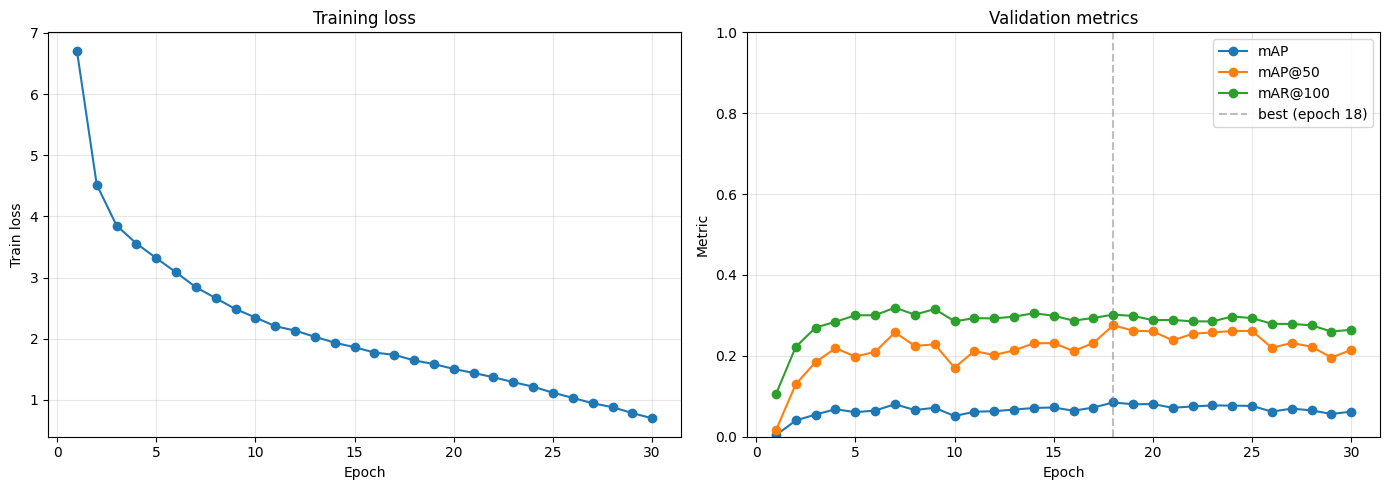

In [ ]:
#Baseline Run
import matplotlib.pyplot as plt


history = train( model=model, train_loader=train_loader, val_loader=val_loader)


epochs      = [h['epoch']      for h in history]
train_loss  = [h['train_loss'] for h in history]
map_full    = [h['map']        for h in history]
map_50      = [h['map_50']     for h in history]
mar_100     = [h['mar_100']    for h in history]


best_epoch = max(history, key=lambda h: h['map_50'])
print(f"\nBest epoch: {best_epoch['epoch']}  "
      f"mAP@50={best_epoch['map_50']:.3f}  "
      f"mAP={best_epoch['map']:.3f}  "
      f"mAR@100={best_epoch['mar_100']:.3f}")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


ax1.plot(epochs, train_loss, marker='o', color='tab:blue')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Train loss')
ax1.set_title('Training loss')
ax1.grid(True, alpha=0.3)


ax2.plot(epochs, map_full, marker='o', label='mAP')
ax2.plot(epochs, map_50,   marker='o', label='mAP@50')
ax2.plot(epochs, mar_100,  marker='o', label='mAR@100')
ax2.axvline(best_epoch['epoch'], color='gray', linestyle='--', alpha=0.5,
            label=f"best (epoch {best_epoch['epoch']})")
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Metric')
ax2.set_title('Validation metrics')
ax2.set_ylim(0, 1)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Baseline run results : 

model overfits past epoch 18, we can add some basic augmentation and move on to failure analysis

In [8]:
from torchvision.transforms import v2

train_transforms = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomAffine(
        degrees=15,
        translate=(0.05, 0.05),   # up to ±5% shift in x, y
        scale=(0.9, 1.1),          # 0.9x to 1.1x scale
    ),
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    v2.SanitizeBoundingBoxes(min_size=1.0),
])

In [9]:
NUM_CLASSES = 2
BATCH_SIZE = 8
max_lr= 3e-4
l2lambda = 1e-5
epochs = 60
patience = 12

In [ ]:
from src.Data import HandDataset

train_dataset = HandDataset('train.json', 'data/training_dataset/training_data/images',transforms=train_transforms)
val_dataset = HandDataset('val.json','data/validation_dataset/validation_data/images')


In [11]:
from torch.utils.data import DataLoader
from src.Data import collate_fn
train_loader=  DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True,collate_fn=collate_fn)
val_loader = DataLoader(val_dataset,batch_size=BATCH_SIZE,shuffle=False,collate_fn=collate_fn)

### Augmented Run

  0%|          | 0/93 [00:00<?, ?it/s]/home/kalzemic/miniconda3/envs/computer_vision/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)
100%|██████████| 93/93 [00:04<00:00, 19.48it/s]


Epoch 1/60 | train_loss=6.7432 | mAP=0.002 | mAP@50=0.010 | mAR@100=0.108 | lr=3.13e-05
  → saved RoboVision.pt (new best mAP@50=0.010)


100%|██████████| 93/93 [00:04<00:00, 19.87it/s]


Epoch 2/60 | train_loss=4.5438 | mAP=0.039 | mAP@50=0.140 | mAR@100=0.232 | lr=8.40e-05
  → saved RoboVision.pt (new best mAP@50=0.140)


100%|██████████| 93/93 [00:04<00:00, 19.41it/s]


...

Epoch 18/60 | train_loss=2.9033 | mAP=0.085 | mAP@50=0.268 | mAR@100=0.332 | lr=2.65e-04


100%|██████████| 93/93 [00:05<00:00, 16.74it/s]


Epoch 19/60 | train_loss=2.8624 | mAP=0.070 | mAP@50=0.214 | mAR@100=0.312 | lr=2.59e-04


100%|██████████| 93/93 [00:06<00:00, 15.08it/s]


Epoch 20/60 | train_loss=2.8391 | mAP=0.074 | mAP@50=0.229 | mAR@100=0.313 | lr=2.53e-04
Early stopping at epoch 20 (no improvement for 12 epochs)

Best epoch: 8  mAP@50=0.299  mAP=0.094  mAR@100=0.319


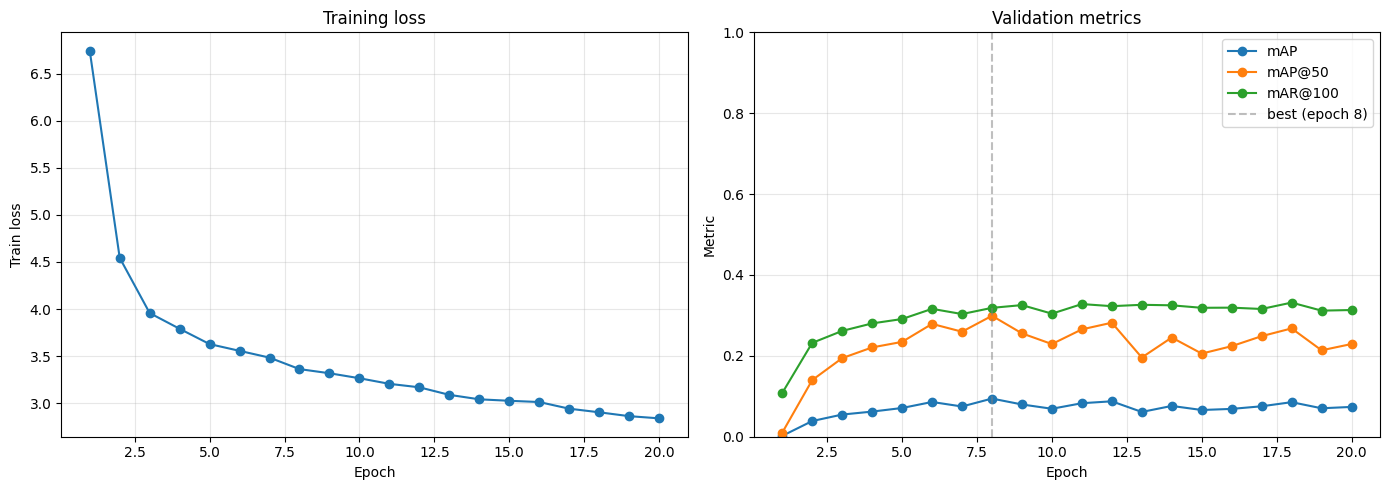

In [14]:
import matplotlib.pyplot as plt


history = train( model=model, train_loader=train_loader, val_loader=val_loader)


epochs      = [h['epoch']      for h in history]
train_loss  = [h['train_loss'] for h in history]
map_full    = [h['map']        for h in history]
map_50      = [h['map_50']     for h in history]
mar_100     = [h['mar_100']    for h in history]


best_epoch = max(history, key=lambda h: h['map_50'])
print(f"\nBest epoch: {best_epoch['epoch']}  "
      f"mAP@50={best_epoch['map_50']:.3f}  "
      f"mAP={best_epoch['map']:.3f}  "
      f"mAR@100={best_epoch['mar_100']:.3f}")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


ax1.plot(epochs, train_loss, marker='o', color='tab:blue')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Train loss')
ax1.set_title('Training loss')
ax1.grid(True, alpha=0.3)


ax2.plot(epochs, map_full, marker='o', label='mAP')
ax2.plot(epochs, map_50,   marker='o', label='mAP@50')
ax2.plot(epochs, mar_100,  marker='o', label='mAR@100')
ax2.axvline(best_epoch['epoch'], color='gray', linestyle='--', alpha=0.5,
            label=f"best (epoch {best_epoch['epoch']})")
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Metric')
ax2.set_title('Validation metrics')
ax2.set_ylim(0, 1)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Now we train with Hagrid

In [ ]:
import json, os, random
from PIL import Image

GESTURES_TO_USE = ['palm', 'stop']

def convert_hagrid(ann_dir, img_root, out_train, out_val, val_user_fraction=0.1, seed=42):
    coco_train = {
        "images": [],
        "annotations": [],
        "categories": [{"id": 1, "name": "hand"}],
    }
    coco_val = {
        "images": [],
        "annotations": [],
        "categories": [{"id": 1, "name": "hand"}],
    }

    # Collect all user_ids from the gesture files we'll use
    all_users = set()
    for gesture in GESTURES_TO_USE:
        with open(os.path.join(ann_dir, f'{gesture}.json')) as f:
            data = json.load(f)
        for entry in data.values():
            all_users.add(entry['user_id'])

    random.seed(seed)
    val_users = set(random.sample(sorted(all_users), int(len(all_users) * val_user_fraction)))
    print(f"Total users: {len(all_users)}, val users: {len(val_users)}")

    image_id = 0
    ann_id = 0

    for gesture in GESTURES_TO_USE:
        img_folder = os.path.join(img_root, f'train_val_{gesture}')
        with open(os.path.join(ann_dir, f'{gesture}.json')) as f:
            data = json.load(f)

        for uuid, entry in data.items():
            img_path = os.path.join(img_folder, f'{uuid}.jpg')
            if not os.path.exists(img_path):
                continue

            with Image.open(img_path) as img:
                W, H = img.size

            coco = coco_val if entry['user_id'] in val_users else coco_train

            coco['images'].append({
                'id': image_id,
                'file_name': f'train_val_{gesture}/{uuid}.jpg',
                'width': W,
                'height': H,
            })

            # Every bbox becomes category_id=1 ("hand"), regardless of gesture label
            for bbox in entry['bboxes']:
                x, y, w, h = bbox
                x, w = x * W, w * W
                y, h = y * H, h * H

                coco['annotations'].append({
                    'id': ann_id,
                    'image_id': image_id,
                    'category_id': 1,
                    'bbox': [x, y, w, h],
                    'area': w * h,
                    'iscrowd': 0,
                    'segmentation': [[x, y, x + w, y, x + w, y + h, x, y + h]],
                })
                ann_id += 1

            image_id += 1

    for out_path, coco in [(out_train, coco_train), (out_val, coco_val)]:
        with open(out_path, 'w') as f:
            json.dump(coco, f)
        print(f"Wrote {len(coco['images'])} images, "
              f"{len(coco['annotations'])} annotations to {out_path}")



convert_hagrid(
    ann_dir='hagrid_data/ann_train_val',
    img_root='hagrid_data/hagrid_30k',
    out_train='hagrid_train.json',
    out_val='hagrid_val.json',
)

(384, 512)
(384, 512)
(384, 512)
(384, 512)


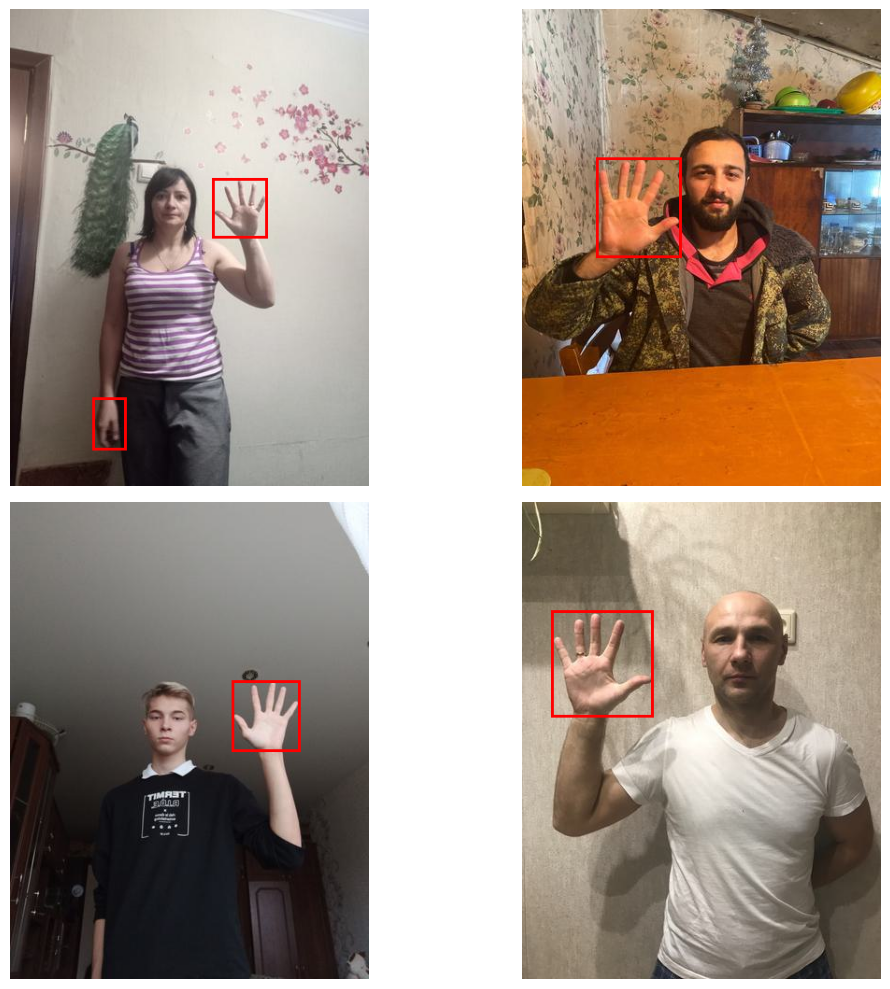

In [21]:
import json, os, random
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

with open('hagrid_train.json') as f:
    coco = json.load(f)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, idx in zip(axes.flat, random.sample(range(len(coco['images'])), 4)):
    info = coco['images'][idx]
    img = Image.open(os.path.join('hagrid_data/hagrid_30k', info['file_name']))
    print(img.size)
    draw = ImageDraw.Draw(img)
    anns = [a for a in coco['annotations'] if a['image_id'] == info['id']]
    for a in anns:
        x, y, w, h = a['bbox']
        draw.rectangle([x, y, x+w, y+h], outline='red', width=3)
    ax.imshow(img)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [17]:
import torch.nn as nn
from torchvision.models.detection.ssdlite import SSDLiteClassificationHead
from torchvision.models.detection import ssdlite320_mobilenet_v3_large
from functools import partial
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from torch.utils.data import DataLoader
from src.Data import HandDataset, collate_fn
from torchvision.transforms import v2


NUM_CLASSES = 2
BATCH_SIZE = 8
max_lr= 3e-4
l2lambda = 1e-5
epochs = 60
patience = 12

train_transforms = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomAffine(
        degrees=15,
        translate=(0.05, 0.05),   # up to ±5% shift in x, y
        scale=(0.9, 1.1),          # 0.9x to 1.1x scale
    ),
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    v2.SanitizeBoundingBoxes(min_size=1.0),
])

train_dataset = HandDataset('hagrid_train.json', 'hagrid_data/hagrid_30k',transforms=train_transforms)
val_dataset   = HandDataset('hagrid_val.json',   'hagrid_data/hagrid_30k')
train_loader=  DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True,collate_fn=collate_fn)
val_loader = DataLoader(val_dataset,batch_size=BATCH_SIZE,shuffle=False,collate_fn=collate_fn)



model = ssdlite320_mobilenet_v3_large(weights='DEFAULT')


in_channels = [module[0][0].in_channels for module in model.head.classification_head.module_list]

num_anchors = model.anchor_generator.num_anchors_per_location()

norm_layer = partial(nn.BatchNorm2d,eps=0.001,momentum=0.03)


model.head.classification_head = SSDLiteClassificationHead(in_channels=in_channels, num_anchors=num_anchors ,num_classes=NUM_CLASSES, norm_layer=norm_layer)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = AdamW(params, lr=max_lr, weight_decay=l2lambda)
scheduler = OneCycleLR(
    optimizer,
    max_lr=max_lr,
    total_steps=epochs * len(train_loader),
    pct_start=0.1,
)


  0%|          | 0/41 [00:00<?, ?it/s]/home/kalzemic/miniconda3/envs/computer_vision/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)
100%|██████████| 41/41 [00:02<00:00, 20.38it/s]


Epoch 1/60 | train_loss=4.4961 | mAP=0.279 | mAP@50=0.499 | mAR@100=0.381 | lr=3.13e-05
  → saved RoboVision.pt (new best mAP@50=0.499)


100%|██████████| 41/41 [00:01<00:00, 21.01it/s]


Epoch 2/60 | train_loss=2.6292 | mAP=0.391 | mAP@50=0.650 | mAR@100=0.497 | lr=8.41e-05
  → saved RoboVision.pt (new best mAP@50=0.650)


100%|██████████| 41/41 [00:01<00:00, 21.47it/s]


...

Epoch 58/60 | train_loss=0.5843 | mAP=0.663 | mAP@50=0.913 | mAR@100=0.732 | lr=1.01e-06


100%|██████████| 41/41 [00:01<00:00, 22.41it/s]


Epoch 59/60 | train_loss=0.5941 | mAP=0.660 | mAP@50=0.912 | mAR@100=0.730 | lr=2.54e-07


100%|██████████| 41/41 [00:01<00:00, 22.07it/s]


Epoch 60/60 | train_loss=0.5910 | mAP=0.663 | mAP@50=0.916 | mAR@100=0.730 | lr=1.20e-09

Best epoch: 52  mAP@50=0.920  mAP=0.663  mAR@100=0.728


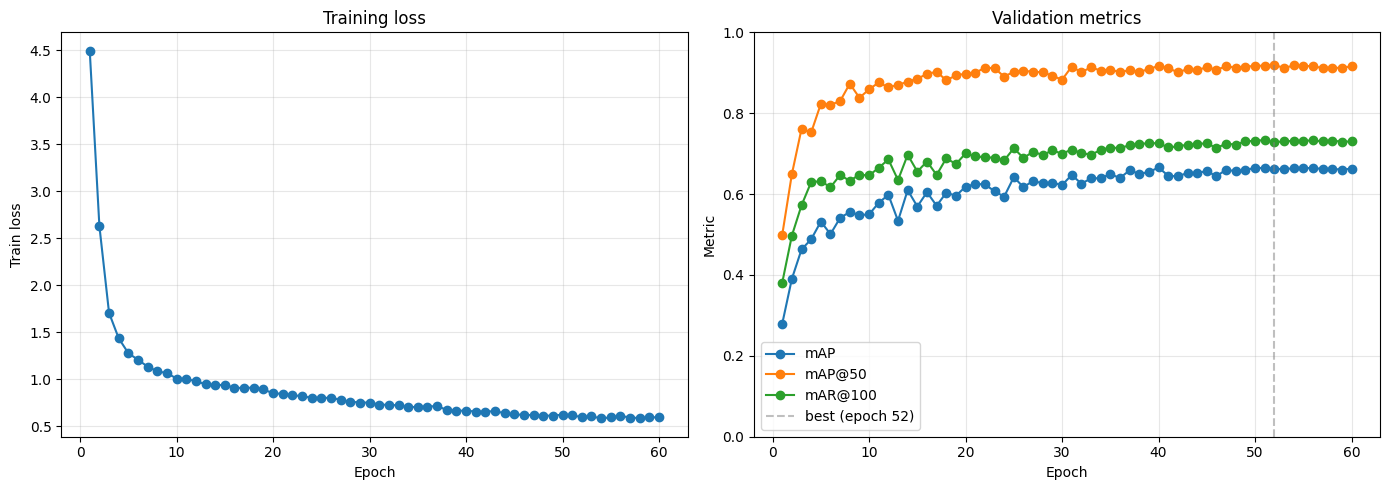

In [18]:
import matplotlib.pyplot as plt


history = train( model=model, train_loader=train_loader, val_loader=val_loader)


epochs      = [h['epoch']      for h in history]
train_loss  = [h['train_loss'] for h in history]
map_full    = [h['map']        for h in history]
map_50      = [h['map_50']     for h in history]
mar_100     = [h['mar_100']    for h in history]


best_epoch = max(history, key=lambda h: h['map_50'])
print(f"\nBest epoch: {best_epoch['epoch']}  "
      f"mAP@50={best_epoch['map_50']:.3f}  "
      f"mAP={best_epoch['map']:.3f}  "
      f"mAR@100={best_epoch['mar_100']:.3f}")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


ax1.plot(epochs, train_loss, marker='o', color='tab:blue')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Train loss')
ax1.set_title('Training loss')
ax1.grid(True, alpha=0.3)


ax2.plot(epochs, map_full, marker='o', label='mAP')
ax2.plot(epochs, map_50,   marker='o', label='mAP@50')
ax2.plot(epochs, mar_100,  marker='o', label='mAR@100')
ax2.axvline(best_epoch['epoch'], color='gray', linestyle='--', alpha=0.5,
            label=f"best (epoch {best_epoch['epoch']})")
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Metric')
ax2.set_title('Validation metrics')
ax2.set_ylim(0, 1)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()